# Analyze W&B Training Runs

Fetch and visualize training metrics from W&B for any round of hyperparameter search.

**Sections:**

1. Configuration (W&B project, entity, group)
2. Run summary table
3. Loss curves (eval + train)
4. mAP curves (mAP@50:95, mAP@50)
5. Learning rate schedules
6. Ranking (best mAP bar chart)
7. Analysis & recommendations

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from moku.runs import fetch_wandb_histories, fetch_wandb_runs

## Configuration

In [3]:
GROUP = "r5"  # Change to analyze a different round

runs_df = fetch_wandb_runs(group=GROUP)
print(f"Found {len(runs_df)} runs in group '{GROUP}'")

# Summary table: key metrics
cols = ["name", "state", "eval/map", "eval/map_50", "eval/map_75", "eval/mar_400", "eval/loss"]
display(runs_df[cols].sort_values("eval/map", ascending=False).reset_index(drop=True))

Found 6 runs in group 'r5'


,name,state,eval/map,eval/map_50,eval/map_75,eval/mar_400,eval/loss
0,r5_lr4e-4_linear500,running,0.557759,0.898243,0.686474,0.666607,5.306854
1,r5_lr3e-4_cos500,finished,0.513481,0.833448,0.632402,0.616086,5.504786
2,r5_lr2e-4_cos500,finished,0.492672,0.766921,0.615155,0.615466,5.517888
3,r5_lr4e-4_cos500,finished,0.380013,0.672259,0.386602,0.507672,5.800489
4,r5_lr5e-4_linear500,running,0.375876,0.786252,0.263627,0.465025,5.537575
5,r5_lr5e-4_cos500,finished,0.347110,0.764219,0.198107,0.402598,5.587478


## Fetch Training History

In [4]:
history = fetch_wandb_histories(group=GROUP)

# Add epoch column from train/epoch (forward-fill within each run)
history = history.sort_values(["run", "_step"])
history["epoch"] = history.groupby("run")["train/epoch"].ffill()
print(f"Loaded {len(history)} history rows across {history['run'].nunique()} runs")

Loaded 9547 history rows across 6 runs


## Eval Loss Curves

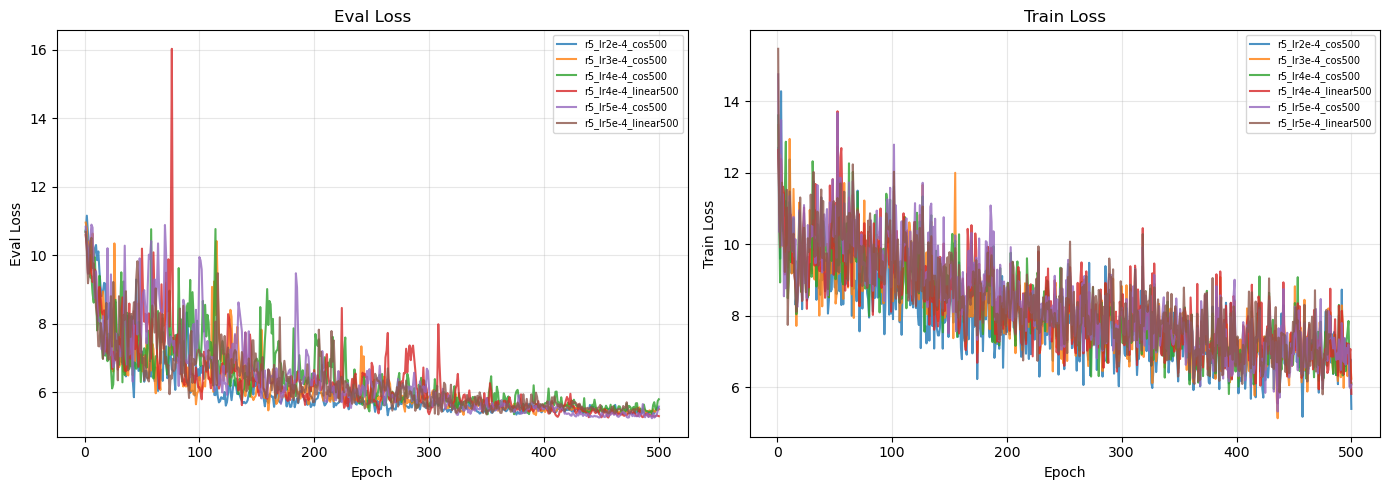

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_name, group in history.groupby("run"):
    eval_data = group.dropna(subset=["eval/loss"])
    if not eval_data.empty:
        axes[0].plot(eval_data["epoch"], eval_data["eval/loss"], label=run_name, alpha=0.8)

    train_data = group.dropna(subset=["train/loss"])
    if not train_data.empty:
        axes[1].plot(train_data["epoch"], train_data["train/loss"], label=run_name, alpha=0.8)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Eval Loss")
axes[0].set_title("Eval Loss")
axes[0].legend(fontsize=7, loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Train Loss")
axes[1].set_title("Train Loss")
axes[1].legend(fontsize=7, loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## mAP Curves

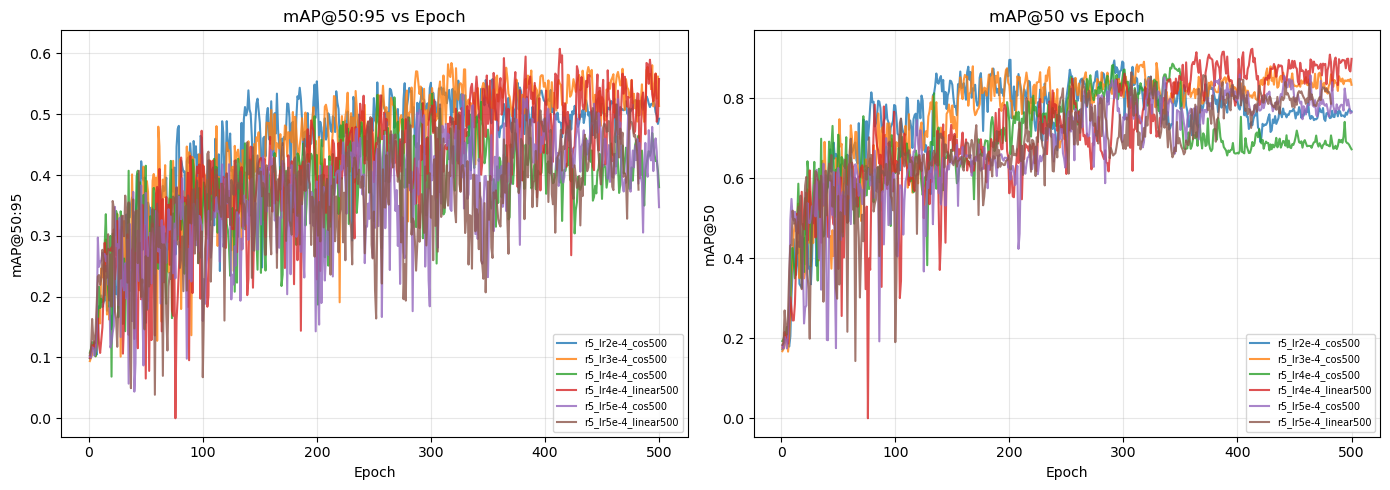

In [6]:
# Use train/eval/map* columns (logged by MAPEvalCallback during training)
# The eval/map* columns only appear at the very end from Trainer final eval
map_col = "train/eval/map" if "train/eval/map" in history.columns else "eval/map"
map50_col = "train/eval/map_50" if "train/eval/map_50" in history.columns else "eval/map_50"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_name, group in history.groupby("run"):
    map_data = group.dropna(subset=[map_col])
    if not map_data.empty:
        axes[0].plot(map_data["epoch"], map_data[map_col], label=run_name, alpha=0.8)

    map50_data = group.dropna(subset=[map50_col])
    if not map50_data.empty:
        axes[1].plot(map50_data["epoch"], map50_data[map50_col], label=run_name, alpha=0.8)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP@50:95")
axes[0].set_title("mAP@50:95 vs Epoch")
axes[0].legend(fontsize=7, loc="lower right")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@50")
axes[1].set_title("mAP@50 vs Epoch")
axes[1].legend(fontsize=7, loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Learning Rate Schedules

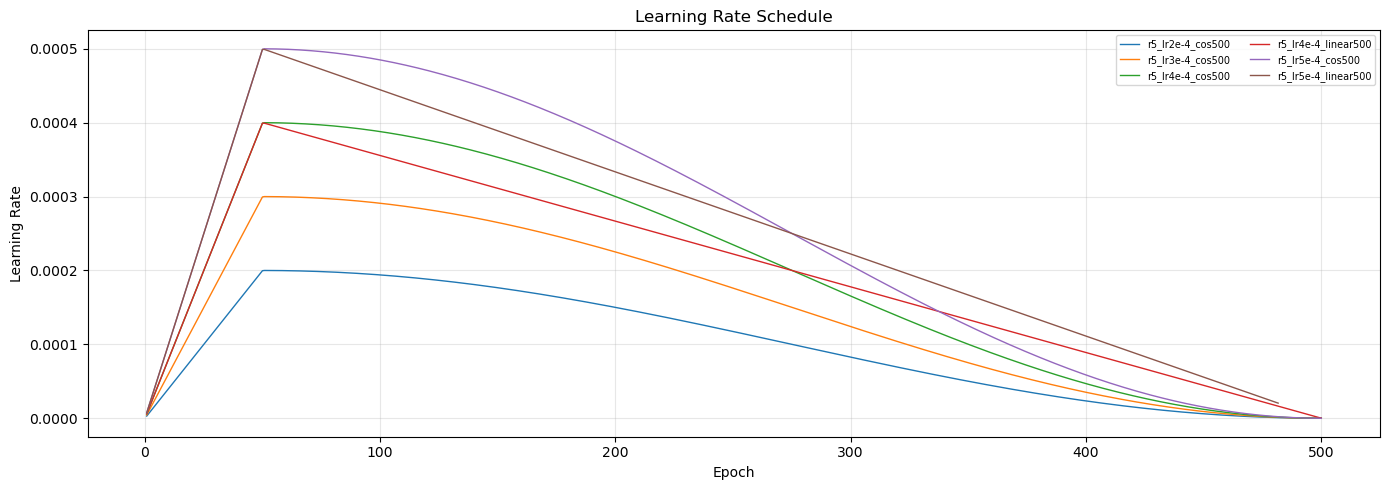

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for run_name, group in history.groupby("run"):
    rd = group.dropna(subset=["train/learning_rate"])
    if rd.empty:
        continue
    ax.plot(rd["epoch"], rd["train/learning_rate"], label=run_name, linewidth=1)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Run Ranking

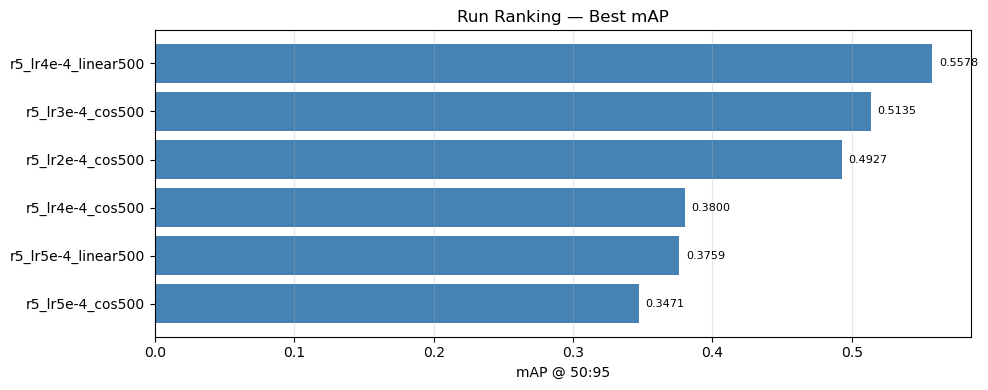

In [8]:
# Best mAP per run (from W&B summary)
ranking = runs_df[["name", "eval/map", "eval/map_50", "eval/map_75"]].copy()
ranking = ranking.sort_values("eval/map", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(ranking) * 0.5)))
bars = ax.barh(ranking["name"], ranking["eval/map"], color="steelblue")
ax.set_xlabel("mAP @ 50:95")
ax.set_title("Run Ranking — Best mAP")
ax.grid(True, axis="x", alpha=0.3)

# Annotate bars
for bar, val in zip(bars, ranking["eval/map"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Best Epoch Per Run

In [9]:
# Find epoch with highest mAP for each run (using train/eval/map from MAPEvalCallback)
map_col = "train/eval/map" if "train/eval/map" in history.columns else "eval/map"
map50_col = "train/eval/map_50" if "train/eval/map_50" in history.columns else "eval/map_50"
map75_col = "train/eval/map_75" if "train/eval/map_75" in history.columns else "eval/map_75"
mar400_col = "train/eval/mar_400" if "train/eval/mar_400" in history.columns else "eval/mar_400"

eval_hist = history.dropna(subset=[map_col])

best_rows = []
for run_name, group in eval_hist.groupby("run"):
    best_idx = group[map_col].idxmax()
    row = group.loc[best_idx]
    best_rows.append({
        "run": run_name,
        "best_epoch": int(row["epoch"]) if pd.notna(row["epoch"]) else "?",
        "mAP": row[map_col],
        "mAP_50": row.get(map50_col, float("nan")),
        "mAP_75": row.get(map75_col, float("nan")),
        "mAR_400": row.get(mar400_col, float("nan")),
    })

best_df = pd.DataFrame(best_rows).sort_values("mAP", ascending=False).reset_index(drop=True)
display(best_df)

,run,best_epoch,mAP,mAP_50,mAP_75,mAR_400
0,r5_lr4e-4_linear500,413,0.607520,0.923377,0.737191,0.714530
1,r5_lr3e-4_cos500,318,0.584135,0.891032,0.694848,0.664195
2,r5_lr2e-4_cos500,354,0.557738,0.826632,0.692600,0.680422
3,r5_lr4e-4_cos500,301,0.533515,0.871535,0.612374,0.636754
4,r5_lr5e-4_cos500,328,0.532266,0.814004,0.634490,0.619224
5,r5_lr5e-4_linear500,308,0.516121,0.793500,0.615015,0.651258


## Analysis & Recommendations

_Fill in after reviewing results above._